In [4]:
import findspark
findspark.init()

In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder. \
    appName("pyspark-1"). \
    getOrCreate()

### Read data

In [8]:
df = spark.read.csv("/dataset/nyc-jobs.csv", header=True)
df.printSchema()

root
 |-- Job ID: string (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: string (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job Category: string (nullable = true)
 |-- Full-Time/Part-Time indicator: string (nullable = true)
 |-- Salary Range From: string (nullable = true)
 |-- Salary Range To: string (nullable = true)
 |-- Salary Frequency: string (nullable = true)
 |-- Work Location: string (nullable = true)
 |-- Division/Work Unit: string (nullable = true)
 |-- Job Description: string (nullable = true)
 |-- Minimum Qual Requirements: string (nullable = true)
 |-- Preferred Skills: string (nullable = true)
 |-- Additional Information: string (nullable = true)
 |-- To Apply: string (nullable = true)
 |-- Hours/Shift: string (nullable = true)
 |-- Work Locatio

### Sample function

In [48]:
def get_salary_frequency(df: DataFrame) -> list:
    row_list = df.select('Salary Frequency').distinct().collect()
    return [row['Salary Frequency'] for row in row_list]

### Example of test function

In [65]:
mock_data = [('A', 'Annual'), ('B', 'Daily')]
expected_result = ['Annual', 'Daily']

In [66]:
def test_get_salary_frequency(mock_data: list, 
                              expected_result: list,
                              schema: list = ['id', 'Salary Frequency']):  
    mock_df = spark.createDataFrame(data = mock_data, schema = schema)
    assert get_salary_frequency(mock_df) == expected_result

+------+--------------------+------------+--------------+--------------------+--------------------+-------------+-----+--------------------+-----------------------------+-----------------+---------------+----------------+--------------------+--------------------+--------------------+-------------------------+--------------------+----------------------+--------------------+--------------------+--------------------+--------------------+---------------------+--------------------+--------------------+--------------------+--------------------+
|Job ID|              Agency|Posting Type|# Of Positions|      Business Title| Civil Service Title|Title Code No|Level|        Job Category|Full-Time/Part-Time indicator|Salary Range From|Salary Range To|Salary Frequency|       Work Location|  Division/Work Unit|     Job Description|Minimum Qual Requirements|    Preferred Skills|Additional Information|            To Apply|         Hours/Shift|     Work Location 1| Recruitment Contact|Residency Require

AttributeError: 'NoneType' object has no attribute 'limit'

In [12]:
# 1.casting salary column string to numeric(double)
from pyspark.sql import functions as F
df = df.withColumn('Salary Range From',F.col('Salary Range From').cast('double'))\
        .withColumn('Salary Range To',F.col('Salary Range To').cast('double'))
df.printSchema()

root
 |-- Job ID: string (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: string (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job Category: string (nullable = true)
 |-- Full-Time/Part-Time indicator: string (nullable = true)
 |-- Salary Range From: double (nullable = true)
 |-- Salary Range To: double (nullable = true)
 |-- Salary Frequency: string (nullable = true)
 |-- Work Location: string (nullable = true)
 |-- Division/Work Unit: string (nullable = true)
 |-- Job Description: string (nullable = true)
 |-- Minimum Qual Requirements: string (nullable = true)
 |-- Preferred Skills: string (nullable = true)
 |-- Additional Information: string (nullable = true)
 |-- To Apply: string (nullable = true)
 |-- Hours/Shift: string (nullable = true)
 |-- Work Locatio

In [15]:
# 2.Whats the number of jobs posting per category (Top 10)?
top_catg = df.groupBy('Job Category').count().orderBy(F.col('count').desc()).limit(10)

top_catg.show()

+--------------------+-----+
|        Job Category|count|
+--------------------+-----+
|Engineering, Arch...|  504|
|Technology, Data ...|  313|
|       Legal Affairs|  226|
|Public Safety, In...|  182|
|Building Operatio...|  181|
|Finance, Accounti...|  169|
|Administration & ...|  134|
|Constituent Servi...|  129|
|              Health|  125|
|Policy, Research ...|  124|
+--------------------+-----+



In [19]:
# 3.Whats the salary distribution per job category?
df_sal_dist = df.groupBy('Job Category').agg(F.avg('Salary Range From').alias('avg_sal_from'),
                                              F.avg('Salary Range To').alias('avg_sal_to'),
                                              F.min('Salary Range From').alias('min_sal_from'),
                                              F.max('Salary Range To').alias('max_sal_to')
                                             )

df_sal_dist.show()

+--------------------+-----------------+------------------+------------+----------+
|        Job Category|     avg_sal_from|        avg_sal_to|min_sal_from|max_sal_to|
+--------------------+-----------------+------------------+------------+----------+
|Administration & ...|          90000.0|          100000.0|     90000.0|  100000.0|
|Health Policy, Re...|         113504.0|          143885.0|     82008.0|  180000.0|
|Administration & ...|          54100.0|           83981.0|     54100.0|   83981.0|
|Information Techn...|          68239.0|           85644.0|     68239.0|   85644.0|
|Finance, Accounti...|          55659.0|           70390.0|     55659.0|   70390.0|
|Engineering, Arch...|         52307.03|          74392.53|      539.12|  118610.0|
|Legal Affairs Pol...|68615.66666666667|109181.66666666667|     54165.0|  168433.0|
|Administration & ...|          45491.0|           60660.0|     45491.0|   60660.0|
|Constituent Servi...|50116.32557829456| 65638.83002945736|        15.5|  15

In [46]:
df.select(F.col('Minimum Qual Requirements'),
          F.col('Minimum Qual Requirements').rlike('baccalaureate|college|university|graduate|Bachelor|Master|PhD').alias('Degree'))\
           .limit(10).show(10)

+-------------------------+------+
|Minimum Qual Requirements|Degree|
+-------------------------+------+
|     "1.	A baccalaurea...|  true|
|     "1. A baccalaurea...|  true|
|     "1. Three years o...| false|
|     "1. Three years o...| false|
|     1. Five years of ...| false|
|     1. Five years of ...| false|
|     "1. A baccalaurea...|  true|
|     Qualification Req...|  true|
|     "1. A master's de...|  true|
|     Qualification Req...| false|
+-------------------------+------+



In [51]:

# 4.Is there any correlation between the higher degree and the salary?
df = df.withColumn('require_degree',
                   F.when(F.col('Minimum Qual Requirements')\
                   .rlike('baccalaureate|college|university|graduate|Bachelor|Master|PhD'),1)\
                    .otherwise(0))

# df.select('require_degree').show(10)

df_degree_sal = df.groupBy('require_degree').agg(F.avg('Salary Range To').alias('avg_sal'))

df_degree_sal.show()

+--------------+-----------------+
|require_degree|          avg_sal|
+--------------+-----------------+
|             1|88874.34846836781|
|             0|76117.37812658885|
+--------------+-----------------+



In [55]:
#5. Whats the job posting having the highest salary per agency?
df_highest_sal = df.groupBy('Agency').agg(F.max('Salary Range To').alias('highest_sal_per_agency'))\
                                          .orderBy(F.col('highest_sal_per_agency').desc())
df_highest_sal.show()

+--------------------+----------------------+
|              Agency|highest_sal_per_agency|
+--------------------+----------------------+
|NYC HOUSING AUTHO...|              234402.0|
|NYC EMPLOYEES RET...|              234402.0|
|   POLICE DEPARTMENT|              234402.0|
|DEPT OF HEALTH/ME...|              225217.0|
|DEPT OF ENVIRONME...|              218587.0|
|DEPT OF DESIGN & ...|              217244.0|
|DISTRICT ATTORNEY...|              208826.0|
|DEPARTMENT OF SAN...|              202744.0|
|DEPT OF INFO TECH...|              189000.0|
|DEPARTMENT OF PRO...|              180000.0|
|OFFICE OF THE COM...|              175000.0|
|CONFLICTS OF INTE...|              170000.0|
|DEPARTMENT OF INV...|              170000.0|
|CIVILIAN COMPLAIN...|              168433.0|
|      LAW DEPARTMENT|              164104.0|
|DEPARTMENT OF BUS...|              162014.0|
|TAXI & LIMOUSINE ...|              160000.0|
|ADMIN FOR CHILDRE...|              156829.0|
|DEPARTMENT OF TRA...|            

In [111]:
# 6. Whats the job positings average salary per agency for the last 2 years?
df = df.withColumn('Posting_Year',
                  F.year(F.to_timestamp(F.col('Posting Date'),"yyyy-MM-dd'T'HH:mm:ss.SSS")))

# df.select('Posting Date').distinct().orderBy(F.col('Posting_Year')).show()
# df.filter(F.col('Posting_Year').isNotNull()).orderBy(F.col('Posting_Year').desc()).select('Posting_Year').show()

last_2_years_avg_sal = df.filter((F.col('Posting_Year') >= 2024) & (F.col('Posting_Year').isNotNull()))\
                         .groupBy('Agency').agg(F.avg('Salary Range To').alias('avg_sal_per_agency'))\
                         .orderBy(F.col('avg_sal_per_agency').desc())

last_2_years_avg_sal.show()


+------+------------------+
|Agency|avg_sal_per_agency|
+------+------------------+
+------+------------------+



In [112]:
# 7. What are the highest paid skills in the US market?
skills_sal = df.select('Preferred Skills','Salary Range To')\
                .groupBy('Preferred Skills')\
                .agg(F.avg('Salary Range To').alias('avg_sal'))\
                .orderBy(F.col('avg_sal').desc())

skills_sal.show()

+--------------------+------------------+
|    Preferred Skills|           avg_sal|
+--------------------+------------------+
| and one year of ...|          225217.0|
|          commercial|219745.66666666666|
|The Deputy Commis...|          218587.0|
|Candidate must ha...|          217244.0|
| all candidates m...|          209585.0|
|â€¢	10+ years of ...|          208826.0|
|â€¢ Integrity â€“...|          202744.0|
|Extensive experie...|          198518.0|
|â€¢	Managerial tr...|          194395.0|
| including making...|          194395.0|
|â€¢ Expert knowle...|          194395.0|
| all candidates m...|          192152.0|
|Certification/lic...|          192152.0|
|Required Skills: ...|          190000.0|
|Strongly Preferre...|          187000.0|
|â€¢	Minimum 10 ye...|          186555.0|
|1.	Minimum 15 yea...|          186555.0|
|Ten years of expe...|          186555.0|
| at least 18 mont...|          183166.0|
|The preferred can...|          180000.0|
+--------------------+------------

In [115]:
#Data Processing

df = df.withColumn('avg_salary',(F.col('Salary Range From') + F.col('Salary Range To')) / 2)

df = df.withColumn('Posting_Year',
                  F.year(F.to_timestamp(F.col('Posting Date'),"yyyy-MM-dd'T'HH:mm:ss.SSS")))

df = df.withColumn('Is_FullTime',
                   F.when(F.col('Full-Time/Part-Time indicator') == 'F',1)\
                    .otherwise(0))


In [116]:
#Save processed data
for col in df.columns:
    new_col = col.replace(" ", "_").replace("/", "_").replace("-", "_")
    df = df.withColumnRenamed(col, new_col)

df.write.mode('overwrite').parquet('/dataset/processed_nyc_jobs')

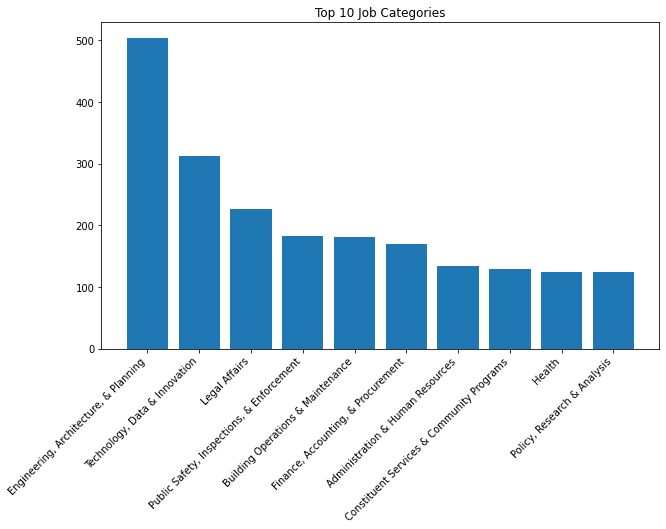

In [127]:
#Visualization
from pyspark.sql import functions as F
top_categories = (
    df.groupBy("Job_Category")
      .agg(F.count("*").alias("count"))
      .orderBy(F.desc("count"))
      .limit(10)
)

top_cat_pd = top_categories.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(top_cat_pd["Job_Category"], top_cat_pd["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Job Categories")
plt.show()

In [126]:
#Testing
    
def test_avg_salary():
    mock_data = [("AgencyA", 50000, 70000), ("AgencyB", 60000, 80000)]
    schema = ["Agency", "Salary Range From", "Salary Range To"]
    mock_df = spark.createDataFrame(mock_data, schema)

    mock_df = mock_df.withColumn("Average_Salary", 
                                 (col("Salary Range From") + col("Salary Range To")) / 2)
    result = [row["Average_Salary"] for row in mock_df.orderBy("Agency").collect()]

    assert result == [60000.0, 70000.0]
    